In [1]:
import os
os.environ.setdefault('MPLCONFIGDIR', '/tmp')

import cloudpickle
import torch
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from RL4CRN.iocrns.iocrn import IOCRN
from RL4CRN.iocrns.reactions import MassAction
from RL4CRN.utils.crn_text_parser import reactions_from_text

import sys
sys.path.append('../..')
from apps.habituation.hallmarks_helpers import compute_habituation_time, rectangular_pulse_program, compute_recovery_time, render_habituation
from apps.habituation.hallmarks import hallmark1_loss, hallmark2_loss, hallmark3_loss, hallmark4_loss, hallmark5_loss, hallmark6_loss, habituation_hallmarks_loss


Compared to run 2:
- Decreased number of species and reactions to 5 and 10 respectively.
- n_dec is set to 4.

## Solver and Plotting

In [2]:
solver = 'CVODE'
ATOL = 1e-9
RTOL = 1e-9

# Plot concentration/output levels on either 'linear' or 'log' scale.
level_scale = 'linear'


def apply_level_scale(ax):
    if level_scale not in {'linear', 'log'}:
        raise ValueError("level_scale must be either 'linear' or 'log'.")
    ax.set_yscale(level_scale)


## Habituation Parameters


In [3]:
checkpoint_path = Path(
    "/local0/home/mfilo/git/GenAI-Net/apps/"
    "habituation_hallmarks_custom_chkpt_run_MA_5S_10R-3.pkl"
)
hof_index = 0

A = 10.0
T = 15.0
Ton = 1.11
n_pulses = 50 

# Hallmark 4 and 5 sweeps.
T_values = [15.0, 20.0, 25.0]
A_values = [10.0, 20.0, 30.0]

# Initial condition convention used by the task.
ic = 'constant'

# Component weights.
hallmark_weights = {
    'hallmark1': 2.0,
    'hallmark2': 1.0,
    'hallmark3': 1.0,
    'hallmark4': 2.0,
    'hallmark5': 2.0,
    'hallmark6': 1.0,
}

# Per-loss keyword arguments.
h1_kwargs = {
    'tolerance': 0.01,
    'n_min': 6,
    'eps': 1e-12,
    'LARGE_NUMBER': 1e4,
    'n_dec': 4, 
}
h2_kwargs = {
    'recovery_tolerance': 0.05,
    'max_gap': 10000.0,
    'search_depth': 16,
}
h3_kwargs = {
    'n_series': 2,
    'recovery_gap_fraction': 0.5,
    'tolerance': 0.01,
}
h4_kwargs = {'tolerance': 0.01}
h5_kwargs = {'tolerance': 0.01}
h6_kwargs = {
    'stricter_habituation_tolerance': 0.005,
    'recovery_tolerance': 0.05,
    'max_gap': 10000.0, 
    'search_depth': 16,
}

amplification_factors = {
    'hallmark1': 3.0,
    'hallmark2': 3.0,
    'hallmark3': 3.0,
    'hallmark4': 3.0,
    'hallmark5': 3.0,
    'hallmark6': 3.0,
}


## Load CRN

In [4]:
# Needed if the checkpoint was saved on GPU but loaded on CPU.
_original_torch_load = torch.load

def torch_load_cpu(*args, **kwargs):
    kwargs.setdefault("map_location", torch.device("cpu"))
    return _original_torch_load(*args, **kwargs)

torch.load = torch_load_cpu

with open(checkpoint_path, "rb") as f:
    checkpoint = cloudpickle.load(f)

hof = checkpoint["hall_of_fame_crns"]

# Hall of fame CRN, exactly as stored during training.
ciff = hof[hof_index].clone()

print("Checkpoint epoch:", checkpoint["epoch"])
print("Hall of fame index:", hof_index)
print("Stored reward:", ciff.last_task_info["reward"])
print("Stored component losses:", ciff.last_task_info["component_losses"])
print(ciff)
ciff.reset()
ciff.solver = solver
ciff.atol = ATOL
ciff.rtol = RTOL


Checkpoint epoch: 286
Hall of fame index: 0
Stored reward: 5.664085344845938
Stored component losses: {'hallmark1': 0.06760173154726272, 'hallmark2': 0.0182647705078125, 'hallmark3': 0.3076923076923077, 'hallmark4': 0.9642857142857143, 'hallmark5': 0.7572463768115942, 'hallmark6': 0.019164265129682997}
Inputs: ['u_1'] 
Species: ['X_1', 'X_2', 'X_3', 'X_4', 'X_5'] 
Output Species: ['X_5'] 
∅ ----> X_1;  [MAK(1.0, u_1)]
X_1 ----> X_5 + X_5;  [MAK(0.6250178217887878)]
X_2 ----> X_3 + X_4;  [MAK(0.3721625506877899)]
X_4 ----> X_3 + X_3;  [MAK(1.5893200635910034)]
X_5 ----> X_3;  [MAK(0.22518150508403778)]
X_1 + X_1 ----> X_2 + X_5;  [MAK(1.4310462474822998)]
X_1 + X_4 ----> X_3 + X_4;  [MAK(0.2879616618156433)]
X_1 + X_5 ----> X_2;  [MAK(0.6914832592010498)]
X_2 + X_4 ----> X_3 + X_3;  [MAK(0.5625508427619934)]
X_2 + X_5 ----> X_3;  [MAK(1.4788665771484375)]
X_3 + X_4 ----> X_2;  [MAK(0.3858860731124878)]


## Build I/O CRN

In [5]:
# reactions = [
#     MassAction([], ["X_1"], input_channels=["u_1"], params=[1.0], params_controllability=[False]),
#     MassAction(["X_1"], ["X_4", "X_4"], params=[0.04084748402237892]),
#     MassAction(["X_4"], ["X_1"], params=[0.04595428705215454]),
#     MassAction(["X_1", "X_1"], ["X_3", "X_4"], params=[0.048695046454668045]),
#     MassAction(["X_1", "X_2"], ["X_2"], params=[0.6668475270271301]),
#     MassAction(["X_1", "X_4"], ["X_2", "X_3"], params=[0.04605919495224953]),
#     MassAction(["X_2", "X_2"], [], params=[0.05097213387489319]),
#     MassAction(["X_3", "X_4"], ["X_1"], params=[0.05004750192165375]),
#     MassAction(["X_4", "X_4"], ["X_2", "X_4"], params=[0.04662628099322319]),
# ]

# reaction_text = """
# CRN hof_2, Reward: 6.59008810628347 
# Inputs: ['u_1'] 
# Species: ['X_1', 'X_2', 'X_3', 'X_4'] 
# Output Species: ['X_4'] 
# ∅ ----> X_1;  [MAK(1.0, u_1)]
# X_2 ----> X_1;  [MAK(0.02719772607088089)]
# X_2 ----> X_3;  [MAK(0.060096289962530136)]
# X_3 ----> X_1;  [MAK(0.0011337964097037911)]
# X_1 + X_1 ----> X_2;  [MAK(3.1093862056732178)]
# X_1 + X_1 ----> X_4;  [MAK(0.002854966791346669)]
# X_2 + X_4 ----> X_2 + X_2;  [MAK(2.424525260925293)]
# X_3 + X_4 ----> X_1 + X_3;  [MAK(0.01578834466636181)]
# X_4 + X_4 ----> X_1 + X_4;  [MAK(0.003490269649773836)]
# """

# reactions = reactions_from_text(reaction_text)

# ciff = IOCRN(reactions, output_labels=['X_4'], solver=solver, atol=ATOL, rtol=RTOL)
# ciff.compile()
# print(ciff)

## Initial Conditions

In [6]:
def inactive_initial_condition(crn):
    return np.zeros(crn.num_species)


def steady_state_initial_condition(crn):
    u_dose = np.array([0.0])
    u_list = [np.array([])]
    initial_guess = np.zeros(crn.num_species)
    x_list, _ = crn.dose_response(u_dose, u_list, initial_guess)
    return x_list[0][:, 0]


if ic == 'zero':
    x0 = inactive_initial_condition(ciff)
elif ic == 'from_ss':
    x0 = steady_state_initial_condition(ciff)
elif ic == 'constant':
    x0 = np.ones(ciff.num_species) * 1e-3
else:
    raise ValueError(f"Unknown initial condition mode: {ic!r}")

print('x0:', x0)
print('dx/dt at zero input:', ciff.rate_function(0.0, x0, np.array([0.0])))


x0: [0.001 0.001 0.001 0.001 0.001]
dx/dt at zero input: [-0.00062886 -0.0003717   0.00377849 -0.00121811  0.00102411]


## Hallmark 1

In [7]:
h1_loss, h1_info = hallmark1_loss(
    ciff, A, T, Ton, n_pulses, x0,
    return_info=True,
    **h1_kwargs,
)
print(f'Hallmark 1 loss: {h1_loss}')
print(h1_info)


Hallmark 1 loss: 0.06760173154726272
{'habituation_time': 26, 'time': array([0.00000000e+00, 9.91071429e-03, 1.98214286e-02, ...,
       7.49980000e+02, 7.49990000e+02, 7.50000000e+02], shape=(75150,)), 'input_signal': array([10., 10., 10., ...,  0.,  0.,  0.], shape=(75150,)), 'response': array([1.00000000e-03, 1.66906417e-03, 3.82556112e-03, ...,
       2.54015535e-05, 2.52457861e-05, 2.50909739e-05], shape=(75150,)), 'peaks': array([1.51243686, 1.48543723, 1.45317474, 1.42573426, 1.40299688,
       1.38398351, 1.36784148, 1.35393567, 1.34180209, 1.3310981 ,
       1.32157391, 1.3130286 , 1.30530377, 1.29827768, 1.29185254,
       1.28594874, 1.28050075, 1.27545405, 1.27076282, 1.2663883 ,
       1.26229736, 1.25846155, 1.25485625, 1.25146004, 1.24825418,
       1.24522219, 1.2423495 , 1.2396232 , 1.23703179, 1.23456498,
       1.23221354, 1.22996917, 1.22782436, 1.22577232, 1.22380689,
       1.22192244, 1.22011386, 1.21837645, 1.21670592, 1.21509833,
       1.21355003, 1.21205769, 

## Visualize Hallmark 1

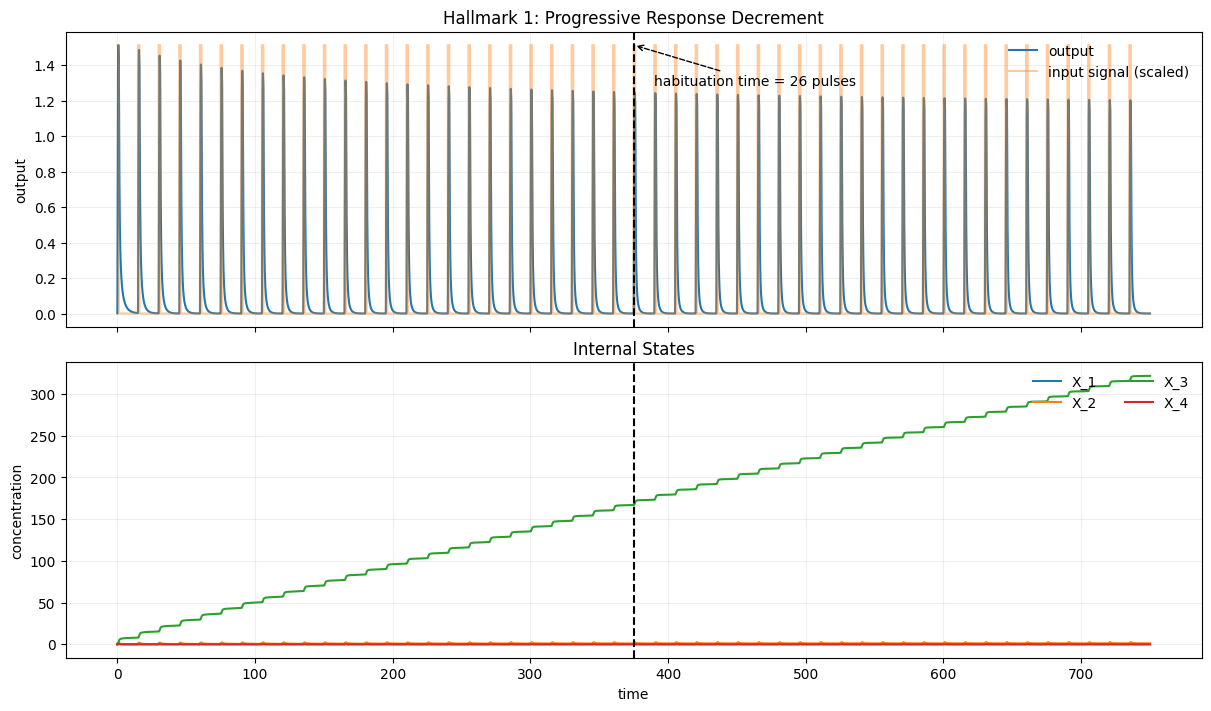

In [8]:
t = h1_info['time']
response = h1_info['response']
input_signal = h1_info['input_signal']
habituation_time = h1_info['habituation_time']
habituation_time_abs = (habituation_time - 1) * T

trajectory = h1_info.get('trajectory')
if trajectory is None:
    u_program, time_segments = rectangular_pulse_program(A, T, Ton, n_pulses)
    _, trajectories, _, _ = ciff.transient_response_piecewise(
        u_nested_list=u_program,
        x0_list=[x0],
        nested_time_horizon=time_segments,
        force=True,
    )
    trajectory = trajectories[0]

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, constrained_layout=True)
ax_out, ax_state = axes

response_max = max(np.max(response), 1e-12)
ax_out.plot(t, response, label='output', color='C0')

scaled_input = input_signal / max(np.max(input_signal), 1e-12) * response_max
ax_out.step(t, scaled_input, where='post', label='input signal (scaled)', color='C1', alpha=0.4)

ax_out.axvline(habituation_time_abs, color='black', linestyle='--', linewidth=1.5)
ax_out.annotate(
    f'habituation time = {habituation_time} pulses',
    xy=(habituation_time_abs, response_max),
    xytext=(habituation_time_abs + T, 0.85 * response_max),
    arrowprops=dict(arrowstyle='->', linestyle='--', color='black'),
    ha='left',
)

ax_out.set_ylabel('output')
ax_out.set_title('Hallmark 1: Progressive Response Decrement')
ax_out.grid(alpha=0.2)
ax_out.legend(frameon=False, loc='upper right')
apply_level_scale(ax_out)

output_labels = set(ciff.output_labels)
for species_idx, species_label in enumerate(ciff.species_labels):
    if species_label in output_labels:
        continue
    ax_state.plot(t, trajectory[species_idx], label=species_label)

ax_state.axvline(habituation_time_abs, color='black', linestyle='--', linewidth=1.5)
ax_state.set_xlabel('time')
ax_state.set_ylabel('concentration')
apply_level_scale(ax_state)
ax_state.set_title('Internal States')
ax_state.grid(alpha=0.2)
ax_state.legend(frameon=False, loc='upper right', ncol=2)

plt.show()


## Hallmark 2

In [9]:
h2_loss, h2_info = hallmark2_loss(
    ciff, A, T, Ton, h1_info['habituation_time'], x0,
    return_info=True,
    **h2_kwargs,
)
print(f'Hallmark 2 loss: {h2_loss}')
print(h2_info)


Hallmark 2 loss: 0.0182647705078125
{'recovery_time': 182.647705078125, 'time': array([0.00000000e+00, 1.00000000e-02, 2.00000000e-02, ...,
       5.87367705e+02, 5.87377705e+02, 5.87387705e+02], shape=(40531,)), 'input_signal': array([10., 10., 10., ...,  0.,  0.,  0.], shape=(40531,)), 'response': array([1.00000000e-03, 1.68147805e-03, 3.87956090e-03, ...,
       4.50458978e-05, 4.47733162e-05, 4.45023847e-05], shape=(40531,)), 'trajectory': array([[1.00000000e-03, 1.00583737e-01, 1.98977306e-01, ...,
        2.44142803e-05, 2.42618790e-05, 2.41104293e-05],
       [1.00000000e-03, 1.04554518e-03, 1.37709690e-03, ...,
        7.16279066e-01, 7.16190242e-01, 7.16101436e-01],
       [1.00000000e-03, 1.03828527e-03, 1.08031514e-03, ...,
        1.81164814e+02, 1.81165036e+02, 1.81165258e+02],
       [1.00000000e-03, 9.87954705e-04, 9.76709911e-04, ...,
        3.70811981e-03, 3.70765809e-03, 3.70719647e-03],
       [1.00000000e-03, 1.68147805e-03, 3.87956090e-03, ...,
        4.50458978e

## Visualize Hallmark 2

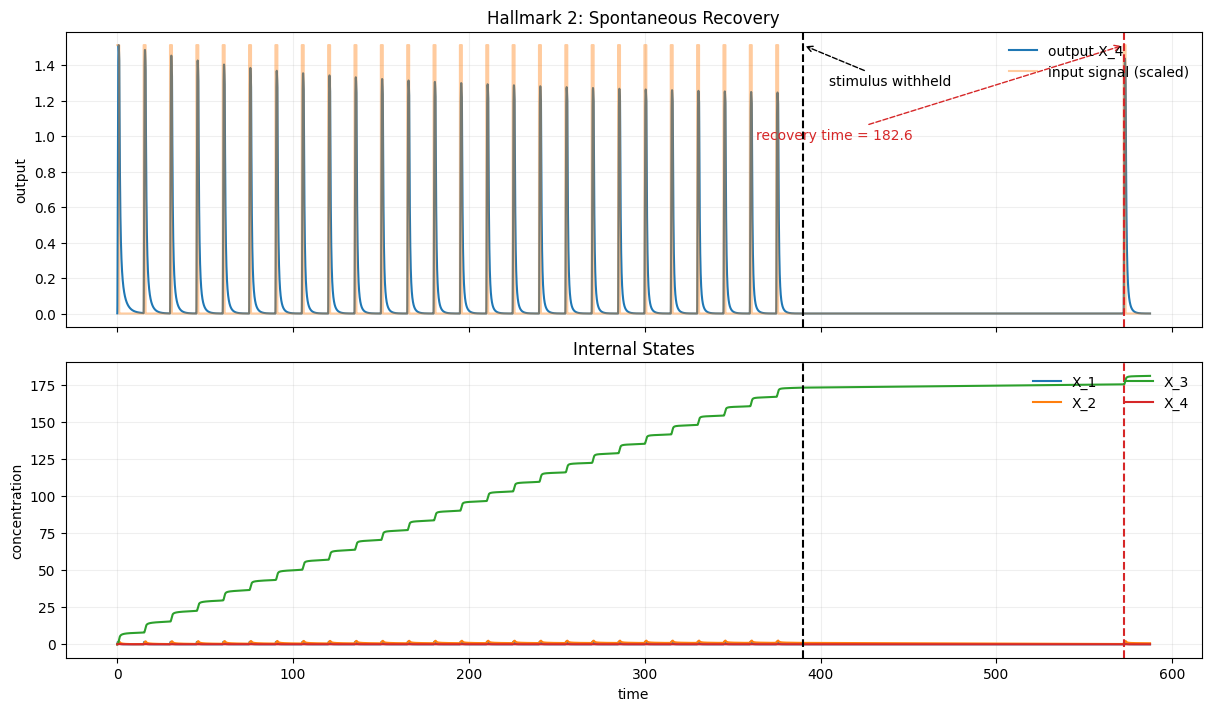

In [10]:
t = h2_info['time']
response = h2_info['response']
input_signal = h2_info['input_signal']
trajectory = h2_info.get('trajectory')
recovery_time = h2_info['recovery_time']
training_end = h1_info['habituation_time'] * T - 0.01
recovery_end = training_end + recovery_time

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, constrained_layout=True)
ax_out, ax_state = axes

response_max = max(np.max(response), 1e-12)
ax_out.plot(t, response, label='output X_4', color='C0')

scaled_input = input_signal / max(np.max(input_signal), 1e-12) * response_max
ax_out.step(t, scaled_input, where='post', label='input signal (scaled)', color='C1', alpha=0.4)

ax_out.axvline(training_end, color='black', linestyle='--', linewidth=1.5)
ax_out.axvline(recovery_end, color='C3', linestyle='--', linewidth=1.5)
ax_out.annotate('stimulus withheld', xy=(training_end, response_max),
                xytext=(training_end + T, 0.85 * response_max),
                arrowprops=dict(arrowstyle='->', linestyle='--', color='black'),
                ha='left')
ax_out.annotate(f'recovery time = {recovery_time:.1f}', xy=(recovery_end, response_max),
                xytext=(recovery_end - 8 * T, 0.65 * response_max),
                arrowprops=dict(arrowstyle='->', linestyle='--', color='C3'),
                ha='right', color='C3')

ax_out.set_ylabel('output')
apply_level_scale(ax_out)
ax_out.set_title('Hallmark 2: Spontaneous Recovery')
ax_out.grid(alpha=0.2)
ax_out.legend(frameon=False, loc='upper right')

if trajectory is not None:
    output_labels = set(ciff.output_labels)
    for species_idx, species_label in enumerate(ciff.species_labels):
        if species_label in output_labels:
            continue
        ax_state.plot(t, trajectory[species_idx], label=species_label)
else:
    ax_state.text(0.5, 0.5, 'trajectory not stored', transform=ax_state.transAxes, ha='center')

ax_state.axvline(training_end, color='black', linestyle='--', linewidth=1.5)
ax_state.axvline(recovery_end, color='C3', linestyle='--', linewidth=1.5)
ax_state.set_xlabel('time')
ax_state.set_ylabel('concentration')
apply_level_scale(ax_state)
ax_state.set_title('Internal States')
ax_state.grid(alpha=0.2)
ax_state.legend(frameon=False, loc='upper right', ncol=2)
plt.show()


## Hallmark 3

In [11]:
h3_loss, h3_info = hallmark3_loss(
    ciff, A, T, Ton, h1_info['habituation_time'], h2_info['recovery_time'], x0,
    return_info=True, n_dec=h1_kwargs['n_dec'],
    **h3_kwargs,
)
print(f'Hallmark 3 loss: {h3_loss}')
print({
    'habituation_times': h3_info['habituation_times'],
    'n_pulses': h3_info['n_pulses'],
    'recovery_gap': h3_info['recovery_gap'],
})


Hallmark 3 loss: 0.3076923076923077
{'habituation_times': array([26.,  8.]), 'n_pulses': 26, 'recovery_gap': 91.3238525390625}


## Visualize Hallmark 3

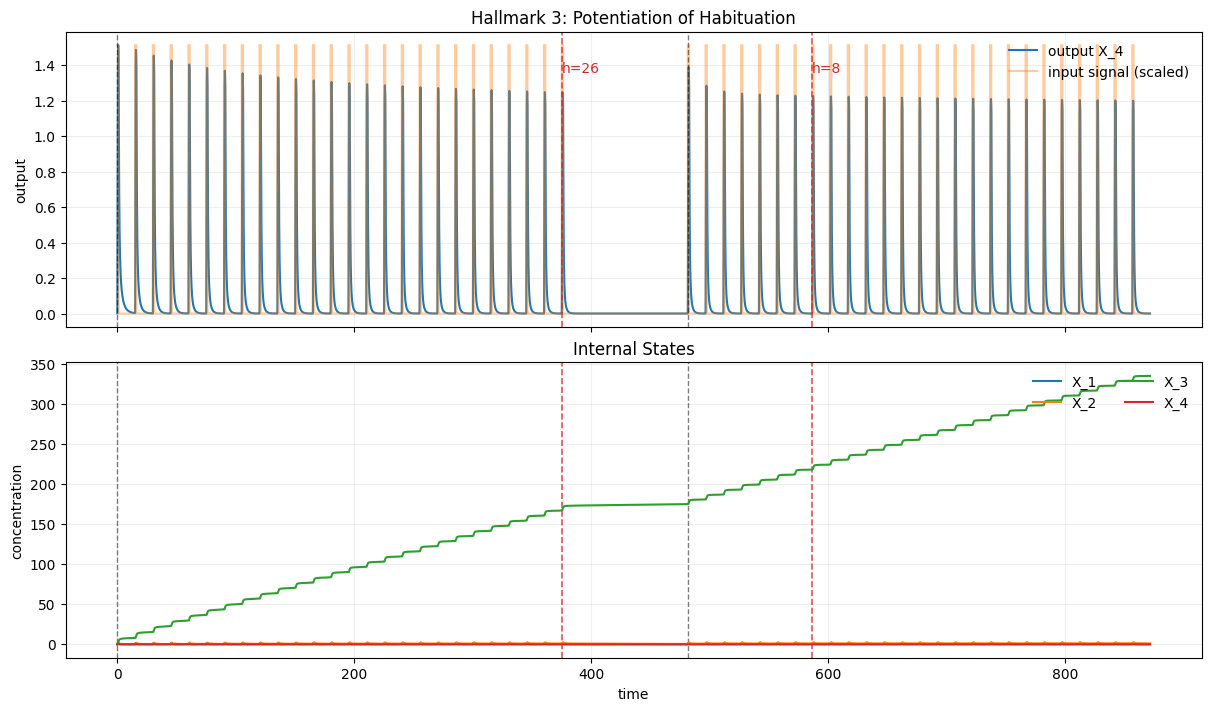

In [12]:
t = h3_info['time']
response = h3_info['response']
input_signal = h3_info['input_signal']
trajectory = h3_info.get('trajectory')

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, constrained_layout=True)
ax_out, ax_state = axes

response_max = max(np.max(response), 1e-12)
ax_out.plot(t, response, label='output X_4', color='C0')

scaled_input = input_signal / max(np.max(input_signal), 1e-12) * response_max
ax_out.step(t, scaled_input, where='post', label='input signal (scaled)', color='C1', alpha=0.4)

series_period = h3_info['n_pulses'] * T + h3_info['recovery_gap']
for series_idx, ht in enumerate(h3_info['habituation_times']):
    series_start = series_idx * series_period
    ax_out.axvline(series_start, color='black', linestyle='--', linewidth=1.0, alpha=0.5)
    ax_state.axvline(series_start, color='black', linestyle='--', linewidth=1.0, alpha=0.5)
    ht_time = series_start + (ht - 1) * T
    ax_out.axvline(ht_time, color='C3', linestyle='--', linewidth=1.2, alpha=0.8)
    ax_state.axvline(ht_time, color='C3', linestyle='--', linewidth=1.2, alpha=0.8)
    ax_out.text(ht_time, 0.9 * response_max, f'h={int(ht)}', color='C3', ha='left')

ax_out.set_ylabel('output')
apply_level_scale(ax_out)
ax_out.set_title('Hallmark 3: Potentiation of Habituation')
ax_out.grid(alpha=0.2)
ax_out.legend(frameon=False, loc='upper right')

if trajectory is not None:
    output_labels = set(ciff.output_labels)
    for species_idx, species_label in enumerate(ciff.species_labels):
        if species_label in output_labels:
            continue
        ax_state.plot(t, trajectory[species_idx], label=species_label)
else:
    ax_state.text(0.5, 0.5, 'trajectory not stored', transform=ax_state.transAxes, ha='center')

ax_state.set_xlabel('time')
ax_state.set_ylabel('concentration')
apply_level_scale(ax_state)
ax_state.set_title('Internal States')
ax_state.grid(alpha=0.2)
ax_state.legend(frameon=False, loc='upper right', ncol=2)
plt.show()


## Hallmark 4

In [13]:
h4_loss, h4_info = hallmark4_loss(
    ciff, A, T_values, Ton, n_pulses, x0,
    return_info=True, n_dec=h1_kwargs['n_dec'],
    **h4_kwargs,
)

print(f'Hallmark 4 frequency term: {h4_loss}')
pd.DataFrame({
    'T': h4_info['T_values'],
    'frequency': h4_info['frequencies'],
    'habituation_time': h4_info['habituation_times'],
})


Hallmark 4 frequency term: 0.9642857142857143


,T,frequency,habituation_time
0,15.0,0.066667,26.0
1,20.0,0.050000,28.0
2,25.0,0.040000,28.0


## Visualize Hallmark 4

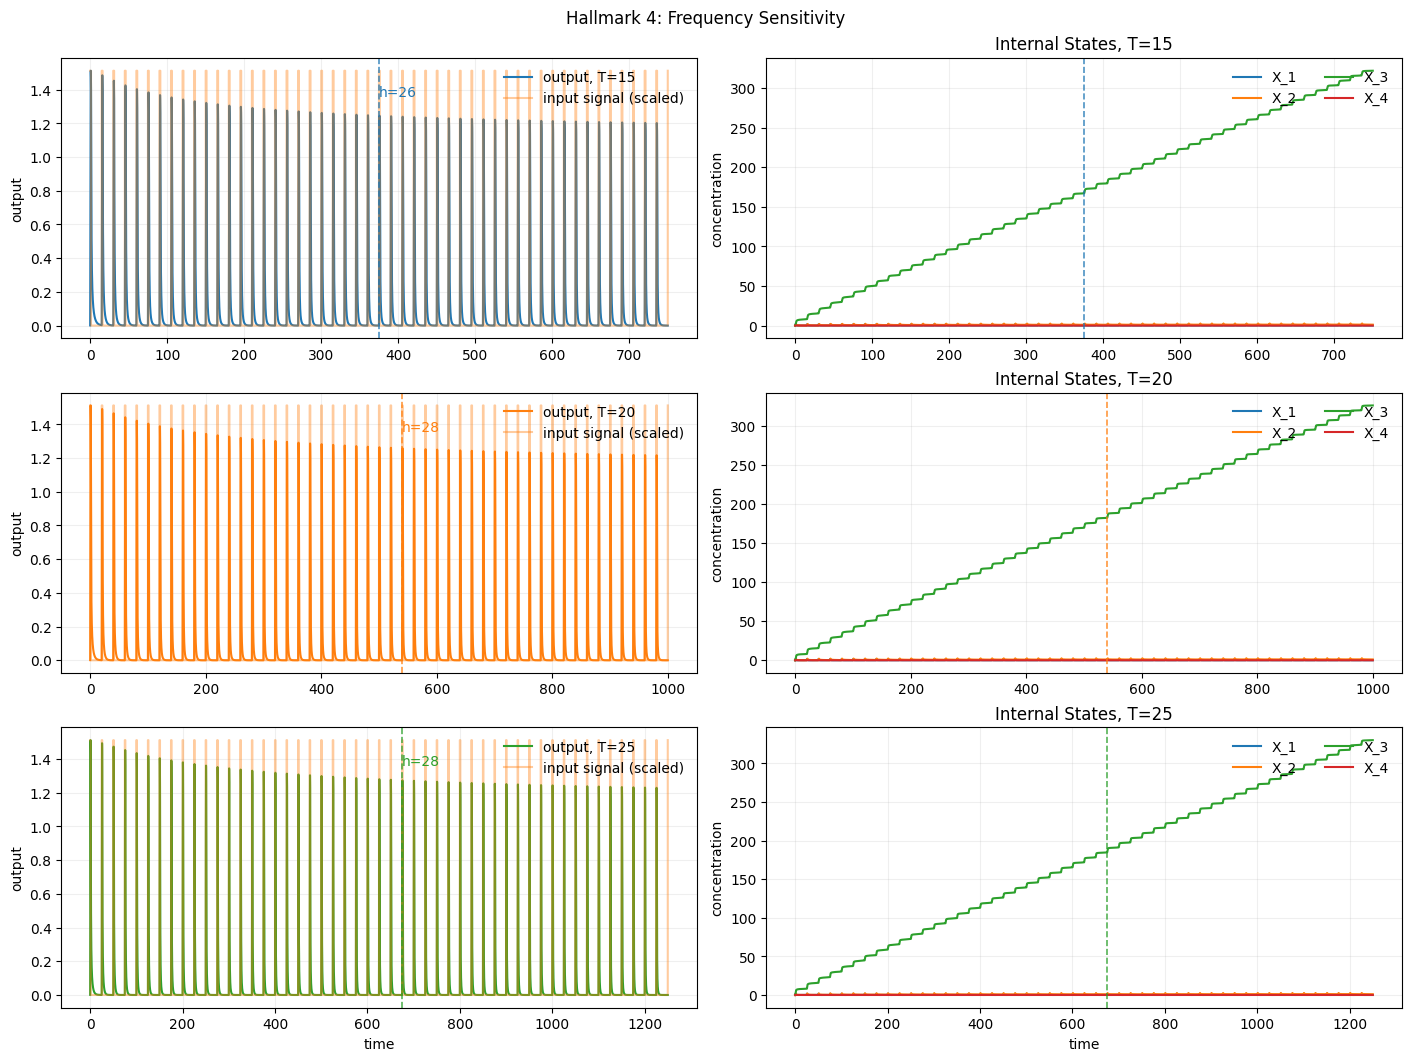

In [14]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
fig, axes = plt.subplots(len(h4_info['runs']), 2, figsize=(14, 3.5 * len(h4_info['runs'])), sharex=False, constrained_layout=True)
axes = np.asarray(axes).reshape(len(h4_info['runs']), 2)
output_labels = set(ciff.output_labels)

for idx, run in enumerate(h4_info['runs']):
    ax_out, ax_state = axes[idx]
    color = colors[idx % len(colors)]
    T_run = run['T']
    h_run = h4_info['habituation_times'][idx]
    t = run['time']
    response = run['response']
    ht_time = (h_run - 1) * T_run
    input_signal = A * ((t % T_run) <= Ton)
    response_max = max(np.max(response), 1e-12)
    scaled_input = input_signal / max(np.max(input_signal), 1e-12) * response_max

    trajectory = run.get('trajectory')
    if trajectory is None:
        u_program, time_segments = rectangular_pulse_program(A, T_run, Ton, n_pulses)
        _, trajectories, _, _ = ciff.transient_response_piecewise(
            u_nested_list=u_program,
            x0_list=[x0],
            nested_time_horizon=time_segments,
            force=True,
        )
        trajectory = trajectories[0]

    ax_out.plot(t, response, color=color, label=f'output, T={T_run:g}')
    ax_out.step(t, scaled_input, where='post', label='input signal (scaled)', color='C1', alpha=0.4)
    ax_out.axvline(ht_time, color=color, linestyle='--', linewidth=1.2, alpha=0.8)
    ax_out.text(ht_time, 0.9 * response_max, f'h={int(h_run)}', color=color, ha='left')
    ax_out.set_ylabel('output')
    apply_level_scale(ax_out)
    ax_out.grid(alpha=0.2)
    ax_out.legend(frameon=False, loc='upper right')

    for species_idx, species_label in enumerate(ciff.species_labels):
        if species_label in output_labels:
            continue
        ax_state.plot(t, trajectory[species_idx], label=species_label)
    ax_state.axvline(ht_time, color=color, linestyle='--', linewidth=1.2, alpha=0.8)
    ax_state.set_ylabel('concentration')
    apply_level_scale(ax_state)
    ax_state.set_title(f'Internal States, T={T_run:g}')
    ax_state.grid(alpha=0.2)
    ax_state.legend(frameon=False, loc='upper right', ncol=2)

axes[-1, 0].set_xlabel('time')
axes[-1, 1].set_xlabel('time')
fig.suptitle('Hallmark 4: Frequency Sensitivity')
plt.show()


## Hallmark 5

In [15]:
h5_loss, h5_info = hallmark5_loss(
    ciff, A_values, T, Ton, n_pulses, x0,
    return_info=True, n_dec=h1_kwargs['n_dec'],
    **h5_kwargs,
)

print(f'Hallmark 5 intensity term: {h5_loss}')
pd.DataFrame({
    'A': h5_info['A_values'],
    'habituation_time': h5_info['habituation_times'],
})


Hallmark 5 intensity term: 0.7572463768115942


,A,habituation_time
0,10.0,26.0
1,20.0,39.0
2,30.0,46.0


## Visualize Hallmark 5

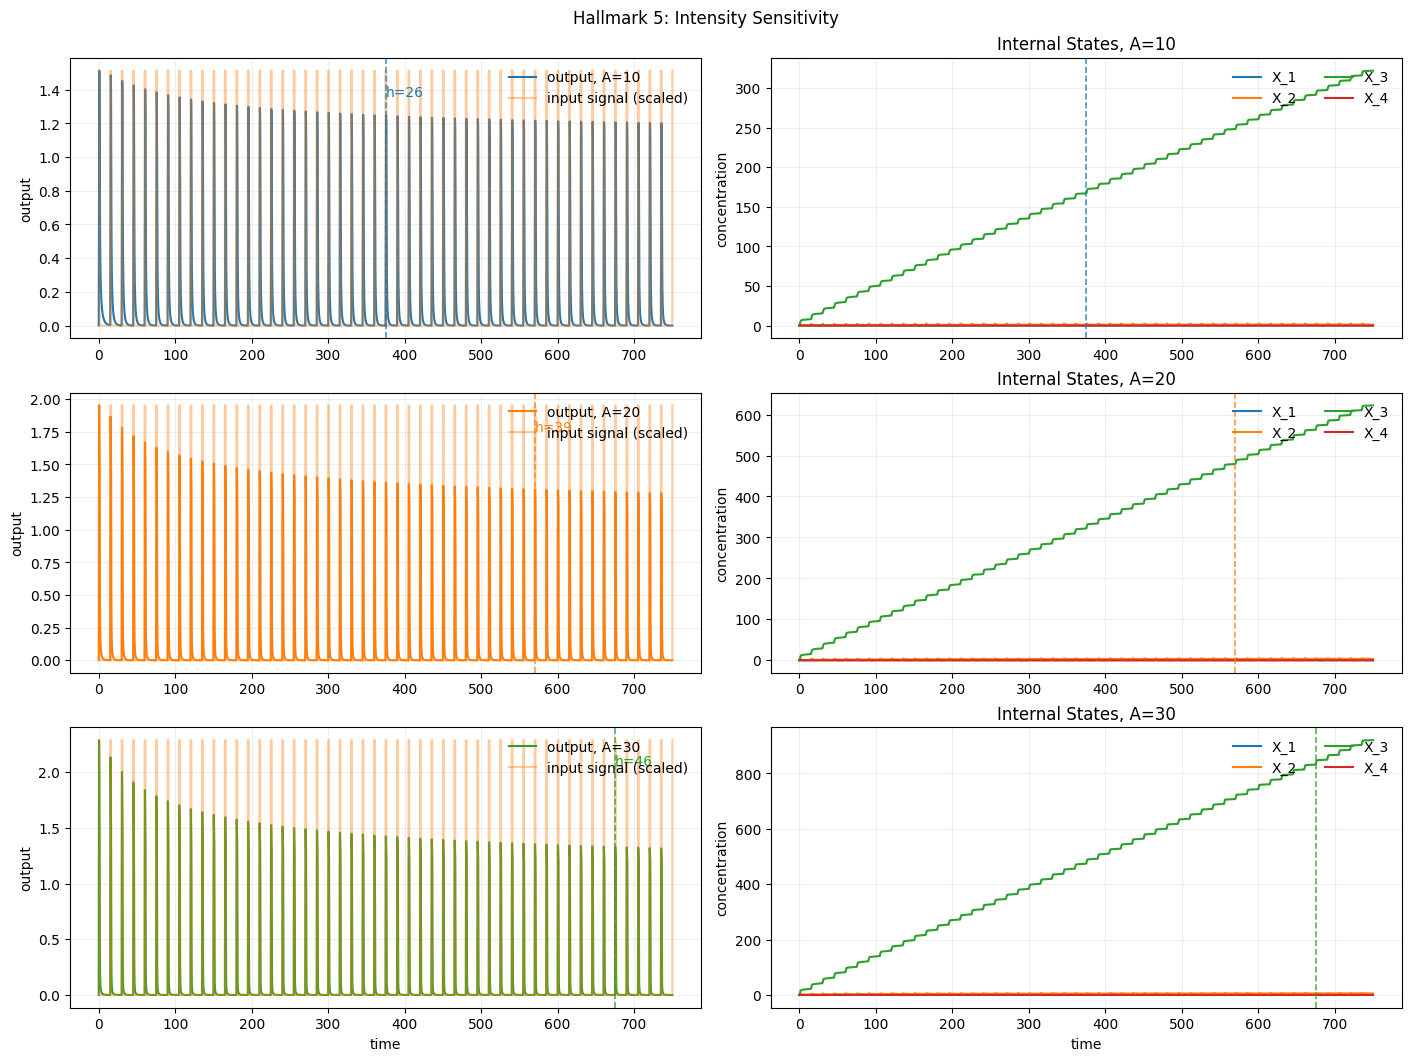

In [16]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
fig, axes = plt.subplots(len(h5_info['runs']), 2, figsize=(14, 3.5 * len(h5_info['runs'])), sharex=False, constrained_layout=True)
axes = np.asarray(axes).reshape(len(h5_info['runs']), 2)
output_labels = set(ciff.output_labels)

for idx, run in enumerate(h5_info['runs']):
    ax_out, ax_state = axes[idx]
    color = colors[idx % len(colors)]
    A_run = run['A']
    h_run = h5_info['habituation_times'][idx]
    t = run['time']
    response = run['response']
    ht_time = (h_run - 1) * T
    input_signal = A_run * ((t % T) <= Ton)
    response_max = max(np.max(response), 1e-12)
    scaled_input = input_signal / max(np.max(input_signal), 1e-12) * response_max

    trajectory = run.get('trajectory')
    if trajectory is None:
        u_program, time_segments = rectangular_pulse_program(A_run, T, Ton, n_pulses)
        _, trajectories, _, _ = ciff.transient_response_piecewise(
            u_nested_list=u_program,
            x0_list=[x0],
            nested_time_horizon=time_segments,
            force=True,
        )
        trajectory = trajectories[0]

    ax_out.plot(t, response, color=color, label=f'output, A={A_run:g}')
    ax_out.step(t, scaled_input, where='post', label='input signal (scaled)', color='C1', alpha=0.4)
    ax_out.axvline(ht_time, color=color, linestyle='--', linewidth=1.2, alpha=0.8)
    ax_out.text(ht_time, 0.9 * response_max, f'h={int(h_run)}', color=color, ha='left')
    ax_out.set_ylabel('output')
    apply_level_scale(ax_out)
    ax_out.grid(alpha=0.2)
    ax_out.legend(frameon=False, loc='upper right')

    for species_idx, species_label in enumerate(ciff.species_labels):
        if species_label in output_labels:
            continue
        ax_state.plot(t, trajectory[species_idx], label=species_label)
    ax_state.axvline(ht_time, color=color, linestyle='--', linewidth=1.2, alpha=0.8)
    ax_state.set_ylabel('concentration')
    apply_level_scale(ax_state)
    ax_state.set_title(f'Internal States, A={A_run:g}')
    ax_state.grid(alpha=0.2)
    ax_state.legend(frameon=False, loc='upper right', ncol=2)

axes[-1, 0].set_xlabel('time')
axes[-1, 1].set_xlabel('time')
fig.suptitle('Hallmark 5: Intensity Sensitivity')
plt.show()


## Hallmark 6


In [17]:
h6_loss, h6_info = hallmark6_loss(
    ciff, A, T, Ton, h1_info['habituation_time'], h2_info['recovery_time'], x0,
    return_info=True, n_dec=h1_kwargs['n_dec'],
    **h6_kwargs,
)

print(f'Hallmark 6 subliminal accumulation term: {h6_loss}')
pd.DataFrame({
    'quantity': [
        'normal recovery time',
        'continued-stimulation recovery time',
        'stricter habituation time',
        'ratio',
    ],
    'value': [
        h6_info['recovery_time'],
        h6_info['continued_recovery_time'],
        h6_info['stricter_habituation_time'],
        h6_loss,
    ],
})



[cvHandleFailure, Error: -15] At t = 80.125337694606, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 590.294025773785, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 80.1500436476877, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 80.1253406024538, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 80.1253282338264, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 80.1500428326982, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 80.1500414298097, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 80.1500470327608, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 80.1253353614679, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 80.1253334423442, unable to satisfy inequality constraints.


[cvHandleF

,quantity,value
0,normal recovery time,182.647705
1,continued-stimulation recovery time,9530.639648
2,stricter habituation time,43.000000
3,ratio,0.019164


## Visualize Hallmark 6


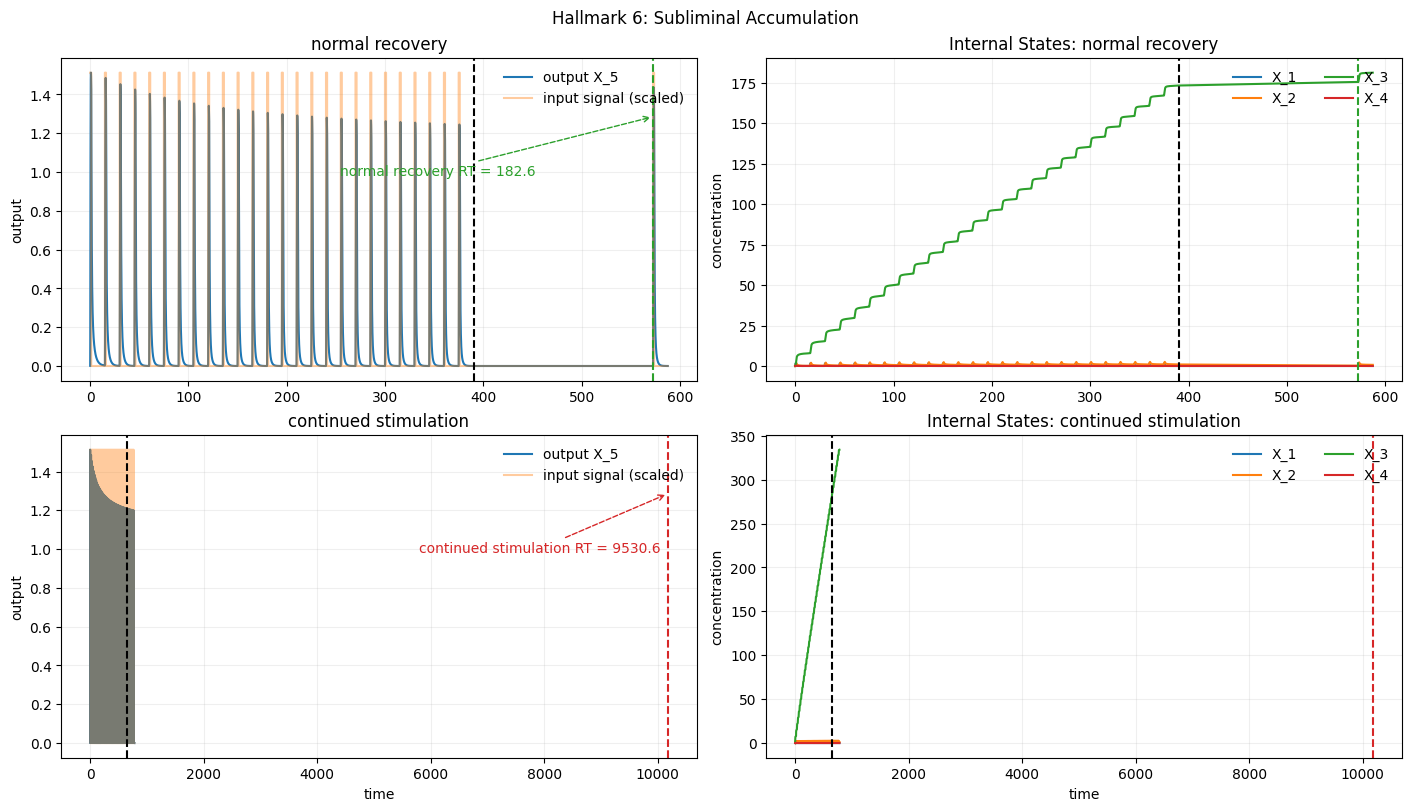

In [18]:
normal_t = h2_info['time']
normal_response = h2_info['response']
normal_input = h2_info['input_signal']
normal_trajectory = h2_info.get('trajectory')
continued_t = h6_info['continued_train_time']
continued_response = h6_info['continued_train_response']
continued_input = h6_info['continued_train_input_signal']
continued_trajectory = h6_info.get('continued_train_trajectory')
normal_recovery_time = h6_info['recovery_time']
continued_recovery_time = h6_info['continued_recovery_time']
normal_training_end = h1_info['habituation_time'] * T - 0.01
continued_training_end = h6_info['stricter_habituation_time'] * T - 0.01
output_label = ciff.output_labels[0] if ciff.output_labels else 'output'

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=False, constrained_layout=True)
output_labels = set(ciff.output_labels)
plots = [
    (axes[0, 0], axes[0, 1], normal_t, normal_response, normal_input, normal_trajectory,
     normal_recovery_time, normal_training_end, 'C2', 'normal recovery'),
    (axes[1, 0], axes[1, 1], continued_t, continued_response, continued_input, continued_trajectory,
     continued_recovery_time, continued_training_end, 'C3', 'continued stimulation'),
]

for ax_out, ax_state, t, response, input_signal, trajectory, recovery_time, training_end, color, label in plots:
    recovery_end = training_end + recovery_time
    response_max = max(np.max(response), 1e-12)
    scaled_input = input_signal / max(np.max(input_signal), 1e-12) * response_max

    ax_out.plot(t, response, label=f'output {output_label}', color='C0')
    ax_out.step(t, scaled_input, where='post', label='input signal (scaled)', color='C1', alpha=0.4)
    ax_out.axvline(training_end, color='black', linestyle='--', linewidth=1.5)
    ax_out.axvline(recovery_end, color=color, linestyle='--', linewidth=1.5)
    ax_out.annotate(f'{label} RT = {recovery_time:.1f}', xy=(recovery_end, 0.85 * response_max),
                    xytext=(recovery_end - 8 * T, 0.65 * response_max),
                    arrowprops=dict(arrowstyle='->', linestyle='--', color=color),
                    ha='right', color=color)
    ax_out.set_ylabel('output')
    apply_level_scale(ax_out)
    ax_out.set_title(label)
    ax_out.grid(alpha=0.2)
    ax_out.legend(frameon=False, loc='upper right')

    if trajectory is not None:
        for species_idx, species_label in enumerate(ciff.species_labels):
            if species_label in output_labels:
                continue
            ax_state.plot(t, trajectory[species_idx], label=species_label)
    else:
        ax_state.text(0.5, 0.5, 'trajectory not stored', transform=ax_state.transAxes, ha='center')
    ax_state.axvline(training_end, color='black', linestyle='--', linewidth=1.5)
    ax_state.axvline(recovery_end, color=color, linestyle='--', linewidth=1.5)
    ax_state.set_ylabel('concentration')
    apply_level_scale(ax_state)
    ax_state.set_title(f'Internal States: {label}')
    ax_state.grid(alpha=0.2)
    ax_state.legend(frameon=False, loc='upper right', ncol=2)

axes[-1, 0].set_xlabel('time')
axes[-1, 1].set_xlabel('time')
fig.suptitle('Hallmark 6: Subliminal Accumulation')
plt.show()


## Combined Hallmark Loss


In [19]:
ciff.reset()
combined_loss, combined_info = habituation_hallmarks_loss(
    ciff, A, T, Ton, n_pulses, x0,
    weights=hallmark_weights,
    T_values=T_values,
    A_values=A_values,
    h1_kwargs=h1_kwargs,
    h2_kwargs=h2_kwargs,
    h3_kwargs=h3_kwargs,
    h4_kwargs=h4_kwargs,
    h5_kwargs=h5_kwargs,
    h6_kwargs=h6_kwargs,
    amplification_factors=amplification_factors,
    return_info=True,
)

print(f'Combined hallmark loss: {combined_loss}')
print('Stored reward:', ciff.last_task_info['reward'])
pd.DataFrame({
    'component': list(combined_info['component_losses'].keys()),
    'raw_loss': [combined_info['raw_component_losses'][name] for name in combined_info['component_losses']],
    'loss': list(combined_info['component_losses'].values()),
    'weight': [combined_info['component_weights'][name] for name in combined_info['component_losses']],
    'amplification': [combined_info['component_amplification_factors'][name] for name in combined_info['component_losses']],
})



[cvHandleFailure, Error: -15] At t = 80.125337694606, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 590.294025773785, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 80.1500436476877, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 80.1253406024538, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 80.1253282338264, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 80.1500428326982, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 80.1500414298097, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 80.1500470327608, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 80.1253353614679, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 80.1253334423442, unable to satisfy inequality constraints.


[cvHandleF

,component,raw_loss,loss,weight,amplification
0,hallmark1,0.067602,0.067602,2.0,3.0
1,hallmark2,0.018265,0.018265,1.0,3.0
2,hallmark3,0.307692,0.307692,1.0,3.0
3,hallmark4,0.964286,0.964286,2.0,3.0
4,hallmark5,0.757246,0.757246,2.0,3.0
5,hallmark6,0.019164,0.019164,1.0,3.0


## Render Combined Hallmarks


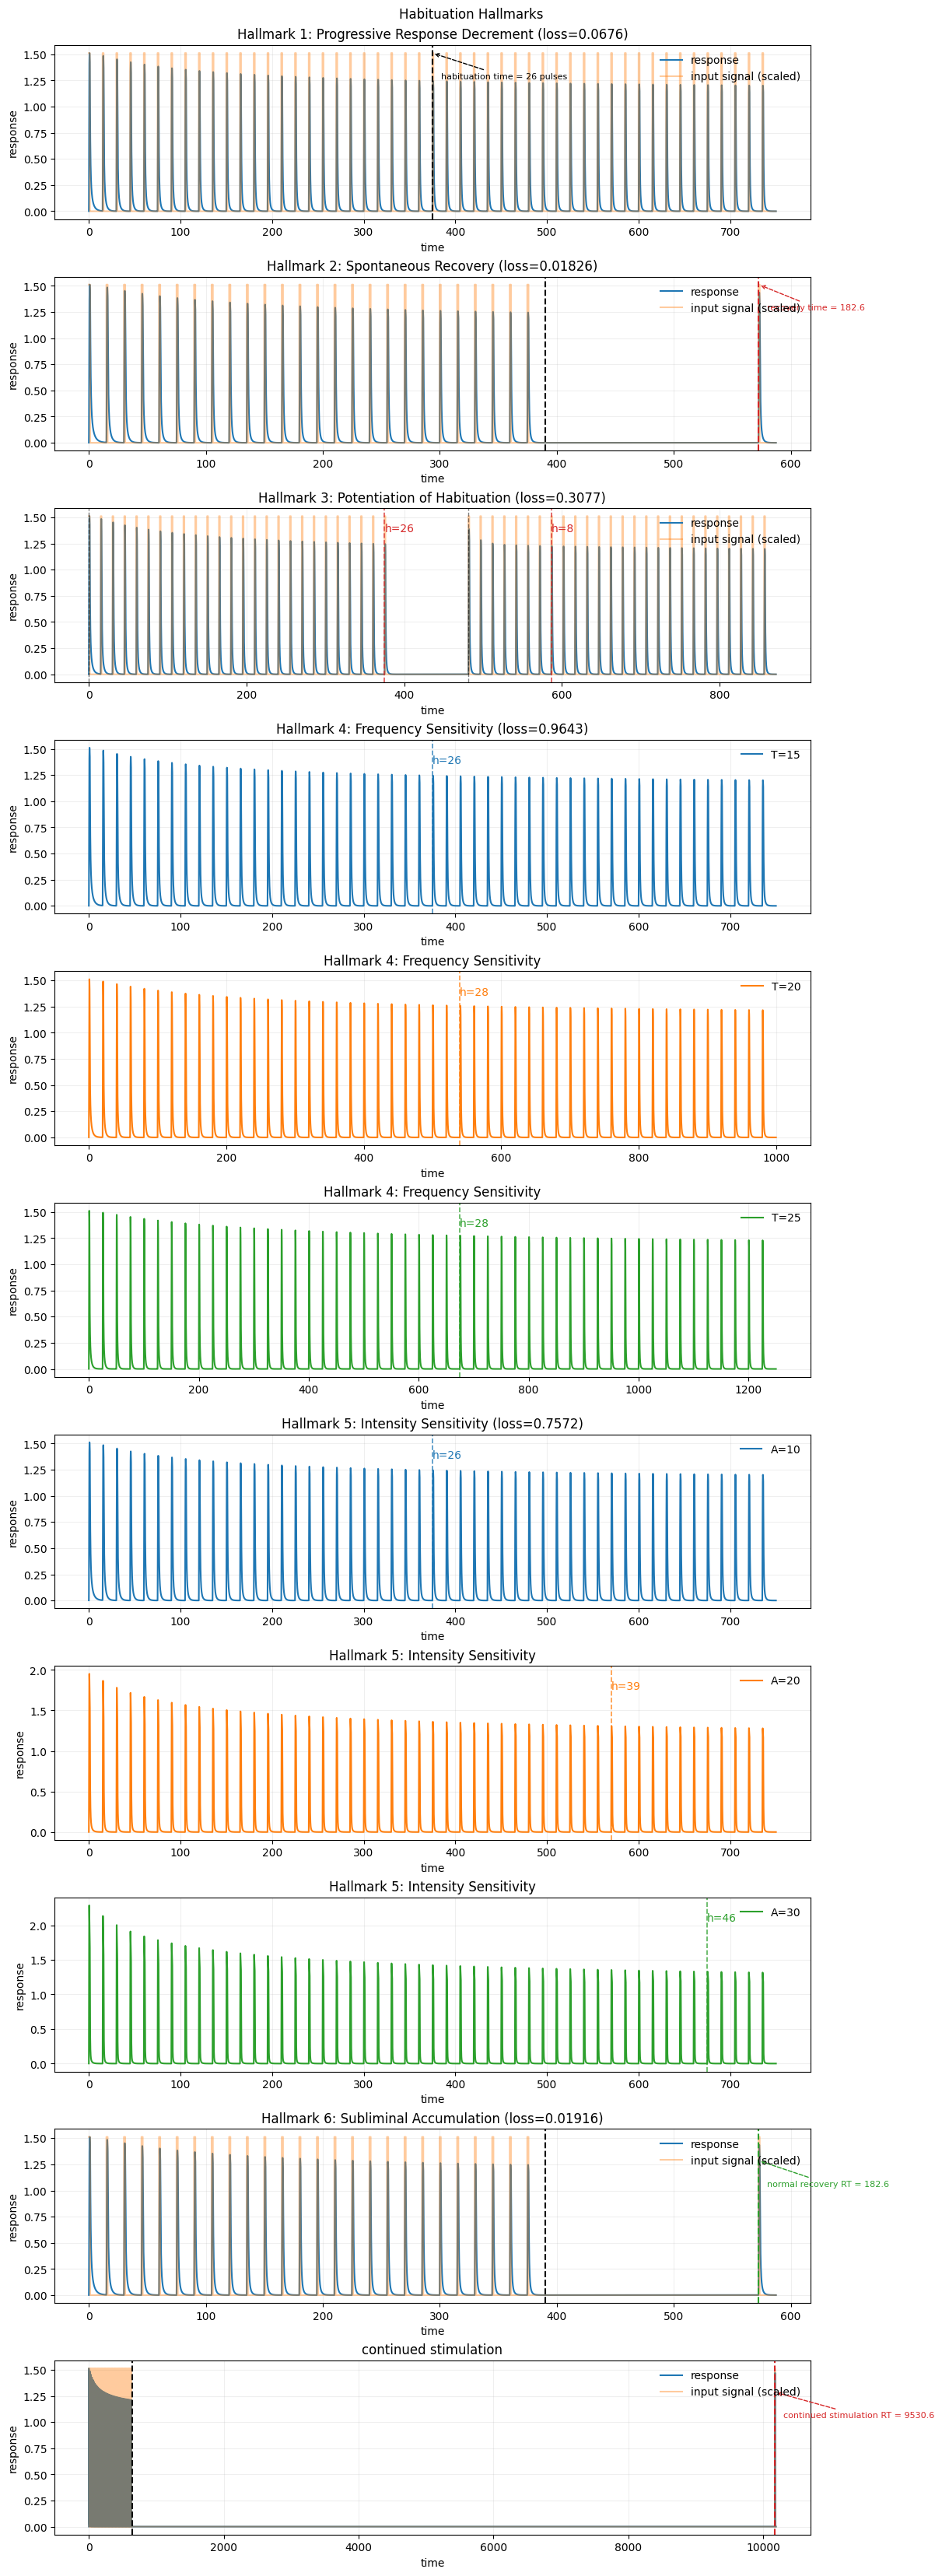

In [23]:
fig, axes = render_habituation(ciff)
for ax in np.ravel(axes):
    apply_level_scale(ax)

fig.savefig(
    "run_Hab_MA_5S_10R-3.pdf",
    bbox_inches="tight",
)
plt.show()



## Hall of Fame Topological Diversity  

Found 30 unique topologies from 30 samples.
Performance data aggregated (Min Loss per topology).
Computing layout (spring)...
Dual Coloring: Face=Loss (Greyscale), Edge=Cluster (Rainbow) with Black Separator


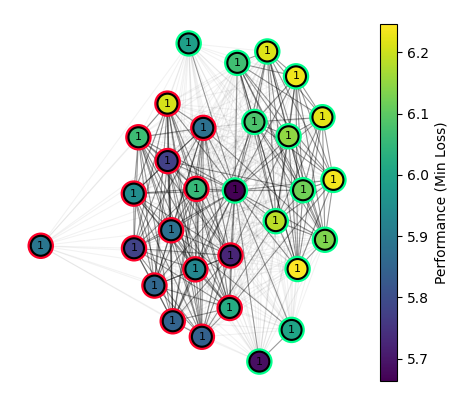

In [21]:
from RL4CRN.utils.visualizations import visualize_crn_diversity

hof_losses = np.asarray([
    crn.last_task_info.get("reward", np.nan)
    for crn in hof
], dtype=float)

fig_topology = visualize_crn_diversity(
    hof,
    perf=hof_losses,
    k=None,
    t=5,
    alpha=0.0,
    unique=False,
    layout_method="spring",
    label_percentile=80,
    figsize=(5, 5),
    graph_dic={
        "fontsize": 8,
        "edgewidth": 0.8,
        "nodesize_multiplier": 300,
        "nodesize_offset": 50,
        "show_colorbar": True,
        "innersize_ratio": 0.8,
        "inner_node_linewidth": 1.5,
        "outer_node_linewidth": 3.0,
        "print_labels": True,
    },
)

if fig_topology is not None:
    fig_topology.suptitle("Hall of Fame Topological Diversity", y=0.98)

fig_topology.savefig(
    "TDG_Hab_MA_5S_10R-3.pdf", 
    bbox_inches="tight",
)

## Reactant-Product Reaction Scatter

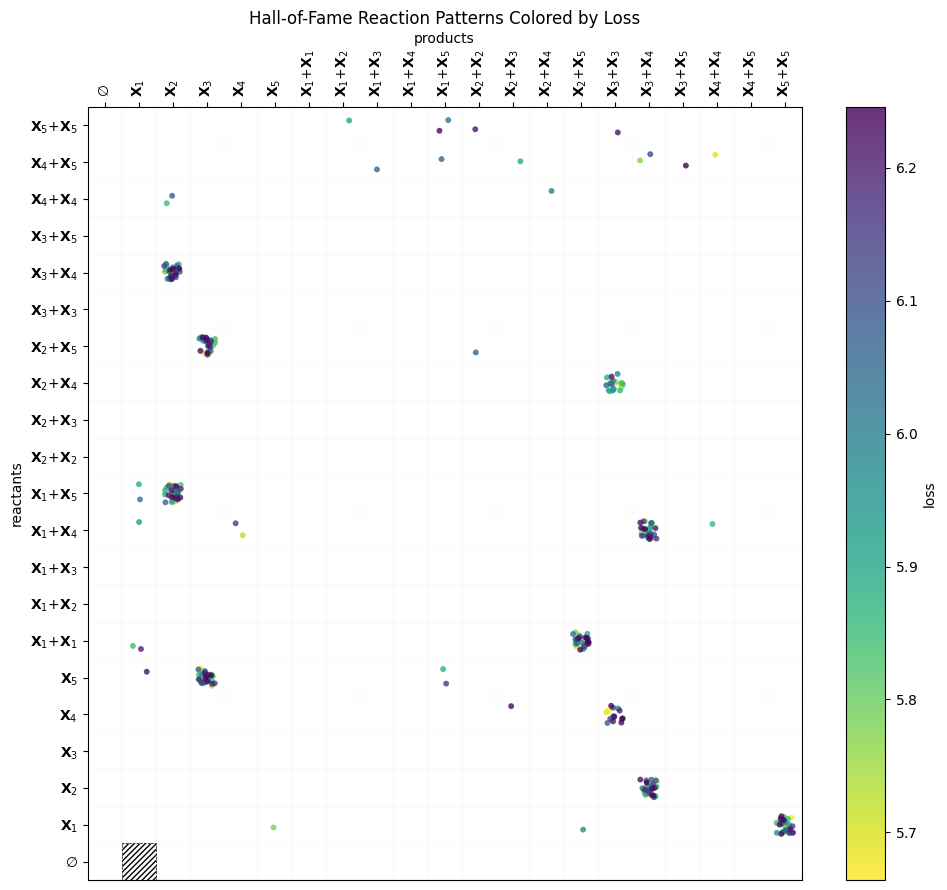

In [22]:
from RL4CRN.utils.visualizations import plot_reactant_product_scatter

hof_losses = np.asarray([
    crn.last_task_info.get("reward", np.nan)
    for crn in hof
], dtype=float)

fig_reaction_scatter = plot_reactant_product_scatter(
    hof,
    perf=hof_losses,
    species_labels=ciff.species_labels,
    max_order=2,
    num_reactions_template=1,
    title="Hall-of-Fame Reaction Patterns Colored by Loss",
    cmap_name="viridis_r",
    max_ticks=30,
    figsize=(10, 9),
    jitter_scale=0.25,
    marker_size=18,
)